<!-- Trabalho Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->
# <font color='blue'>Data Science Academy</font>
# <font color='blue'>Fundamentos de Linguagem Python - Do Básico a Aplicações de IA</font>
# <font color='blue'>Lista 5 de Exercícios</font>

**ATENÇÃO**: Esta lista de exercícios pode requerer pesquisa complementar. A solução será apresentada no próximo capítulo.

In [81]:
# Imports
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

#### Exercício 1: Análise de Distribuição de Receita Mensal

- Contexto: Uma loja online deseja entender a variabilidade das receitas mensais para ajustar seu fluxo de caixa.

- Tarefa: Carregue os dados simulados de receita mensal e apresente um relatório com média, mediana, desvio-padrão, assimetria e curtose. Visualize a distribuição e interprete se ela é simétrica, à direita ou à esquerda.

- Resultado esperado: Descreva a tendência central e a dispersão, comente se a média representa bem o conjunto.

In [82]:
# Seed
np.random.seed(10)

# Cria dados de receita
receita = np.random.normal(50000, 8000, 100)

# Cria o dataframe
df = pd.DataFrame({'Receita': receita})

# Visualiza os dados
df.head()

,Receita
0,60652.692033
1,55722.231795
2,37636.797663
3,49932.929201
4,54970.687791


In [83]:
# Solução
Total = round(df['Receita'].sum(), 2)
Media = round(df['Receita'].mean(),2)
Mediana = round(df['Receita'].median(),2)
Desvio_Padrao = round(df['Receita'].std(),2)
Assimetria = round(df['Receita'].skew(),4)
Curtose = round(df['Receita'].kurtosis(),4)

------------- Relatório de Receita Mensal -------------

- Valor Total Receita Mensal: R$ 5.063.533,33
- Média da Receita Mensal: R$ 50.635,33
- Mediana da Receita Mensal: R$ 50.754,95
- Desvio Padrão da Receita Mensal: R$ 7.775,29

------------- Análise de Dados -------------



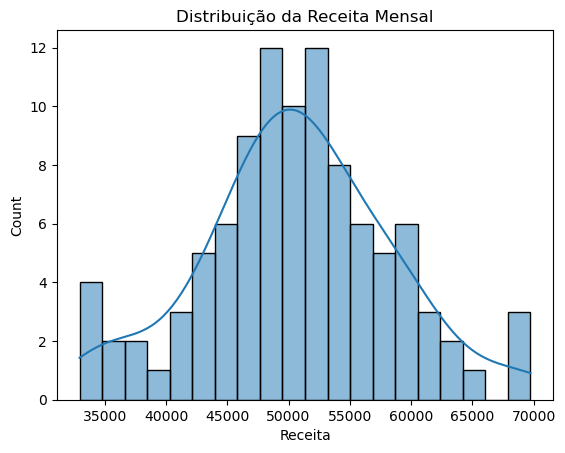

O valor da Assimetria 0.0138 é positivo e indica quase uma simetria pois está próxima a zero. Tendo uma distribuição de receita bem equilibrada.

O valor da Curtose 0.1935 é proximo a zero, o que indica um formato próximo ao normal (mesocúrtica) com dados centrais de maior densidade, sem dados extremos relevantes.

Em conclusão, a média da Receita Mensal, representa o conjunto como um todo, visto que a a assimetria e cutosse estão equilibradas e próximo ao centro.
----------------------------------------------------------------------------------------------------------------------------------------



In [85]:
# Relatório Receita
sns.histplot(df['Receita'], bins=20, kde=True)
plt.title("Distribuição da Receita Mensal")

print("------------- Relatório de Receita Mensal -------------\n")
print(f"- Valor Total Receita Mensal: R$ {Total:,.2f}".replace(",","X").replace(".",",").replace("X","."))
print(f"- Média da Receita Mensal: R$ {Media:,.2f}".replace(",","X").replace(".",",").replace("X","."))
print(f"- Mediana da Receita Mensal: R$ {Mediana:,.2f}".replace(",","X").replace(".",",").replace("X","."))
print(f"- Desvio Padrão da Receita Mensal: R$ {Desvio_Padrao:,.2f}\n".replace(",","X").replace(".",",").replace("X","."))
print("------------- Análise de Dados -------------\n")

plt.show()
print(f"O valor da Assimetria {Assimetria} é positivo e indica quase uma simetria pois está próxima a zero. Tendo uma distribuição de receita bem equilibrada.\n")
print(f"O valor da Curtose {Curtose} é proximo a zero, o que indica um formato próximo ao normal (mesocúrtica) com dados centrais de maior densidade, sem dados extremos relevantes.\n")
print("Em conclusão, a média da Receita Mensal, representa o conjunto como um todo, visto que a a assimetria e cutosse estão equilibradas e próximo ao centro.")
print("----------------------------------------------------------------------------------------------------------------------------------------\n")

#### Exercício 2: Desempenho por Segmento de Cliente

- Contexto: Uma empresa quer comparar o valor médio gasto por clientes novos e antigos.

- Tarefa: Para os dois grupos (clientes novos e antigos), calcule média, mediana e desvio-padrão, e compare visualmente com boxplot. Discuta se há sobreposição entre os grupos e qual apresenta maior variabilidade.

- Resultado esperado: Indique diferenças de média e dispersão, e o que isso sugere sobre o perfil de gasto.

In [86]:
# Seed
np.random.seed(5)

# Dataframe
clientes = pd.DataFrame({
    'Grupo': ['Novo']*80 + ['Antigo']*80,
    'Gasto': np.concatenate([np.random.normal(180, 40, 80),
                             np.random.normal(230, 35, 80)])
})

# Visualiza os dados
clientes.sample(10)

,Grupo,Gasto
122,Antigo,216.853270
119,Antigo,229.406914
143,Antigo,207.787163
40,Novo,167.765879
4,Novo,184.384394
27,Novo,165.467565
150,Antigo,279.075832
106,Antigo,200.373598
82,Antigo,256.100443
50,Novo,236.535921


------------- Relatório Comparativo de Gastos -------------

        count        mean        std         min         25%         50%  \
Grupo                                                                      
Antigo   80.0  232.921448  38.388523  148.253236  205.127578  231.443713   
Novo     80.0  182.692648  38.652415   65.612481  162.151568  177.481971   

               75%         max  
Grupo                           
Antigo  257.624944  318.228267  
Novo    206.822797  277.230847  

Os clientes antigos gastam, em média, mais (R$ 232,92) que os novos (R$ 182.69) o que indica um perfil de consumo mais elevado. Já o desvio padrão entre os dois é equilibrado, aproximadamente 38 o que mostra variabilidade semelhante nos gastos.




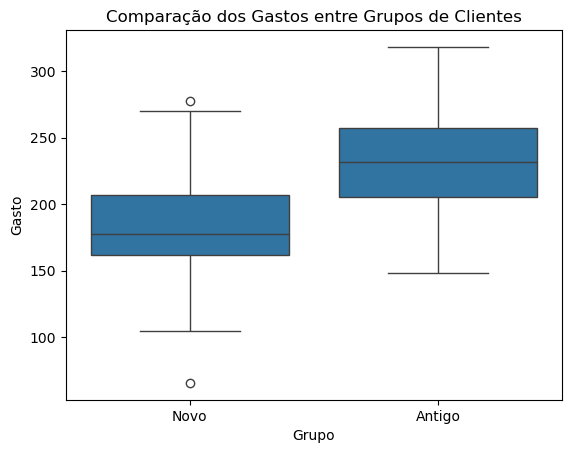

No gráfico é possível ver que há pouca sobreposição, já que os quartis entre os grupos de clientes possuem valores diferentes, sendo assim, se conclui que os clientes Antigos possuem um valor de gasto superior pois já estão fidelizados, quanto os Clientes Novos ainda possuem um gasto menor.
----------------------------------------------------------------------------------------------------------------------------------------



In [87]:
# Solução
resumo = clientes.groupby('Grupo')['Gasto'].describe()

sns.boxplot(data=clientes, x='Grupo', y='Gasto')
plt.title("Comparação dos Gastos entre Grupos de Clientes")

print("------------- Relatório Comparativo de Gastos -------------\n")
print(f"{resumo}\n")
print("Os clientes antigos gastam, em média, mais (R$ 232,92) que os novos (R$ 182.69) o que indica um perfil de consumo mais elevado. Já o desvio padrão entre os dois é equilibrado, aproximadamente 38 o que mostra variabilidade semelhante nos gastos.\n\n")
plt.show()
print("No gráfico é possível ver que há pouca sobreposição, já que os quartis entre os grupos de clientes possuem valores diferentes, sendo assim, se conclui que os clientes Antigos possuem um valor de gasto superior pois já estão fidelizados, quanto os Clientes Novos ainda possuem um gasto menor.")
print("----------------------------------------------------------------------------------------------------------------------------------------\n")

#### Exercício 3: Correlação Entre Horas de Estudo e Nota

- Contexto: Um professor quer saber se o tempo de estudo está associado ao desempenho dos alunos.

- Tarefa: Calcule a correlação de Pearson e gere o gráfico de dispersão com linha de regressão. Interprete o grau e a direção da relação.

- Resultado esperado: Descreva se há correlação positiva, negativa ou nula e o que isso significa em termos práticos.

In [88]:
# Seed
np.random.seed(2)

# Dados
horas = np.random.uniform(1, 10, 50)
notas = 5*horas + np.random.normal(0, 5, 50)

# Dataframe
df = pd.DataFrame({'Horas': horas, 'Nota': notas})

# Visualiza os dados
df.head()

,Horas,Nota
0,4.923954,20.474094
1,1.233336,6.605232
2,5.946962,34.736641
3,4.917902,22.684045
4,4.783310,22.038204


------------- Relatório de Correlação de Horas de Estudo e Nota -------------

A correlação (0.915) é positiva e forte entre as horas de estudo e a nota. Ou seja, quanto mais horas o aluno estuda, maior será sua nota. Sendo assim a regressão é linear e direta pois está perto do 1.



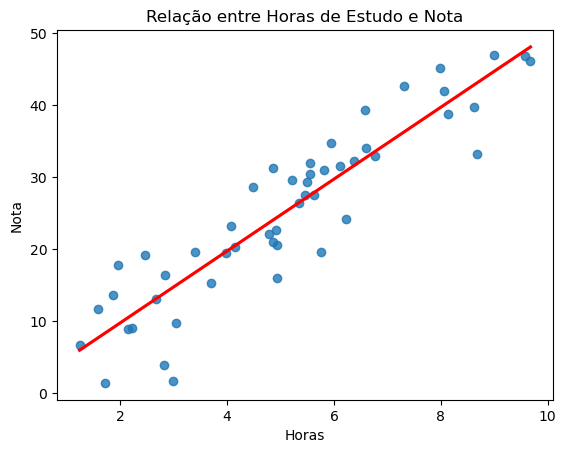

----------------------------------------------------------------------------------------------------------------------------------------



In [89]:
# Solução
matriz = df.corr()
correlacao = round(float(matriz.loc['Horas']['Nota']),3)
sns.regplot(data=df, x='Horas', y='Nota', ci=None, line_kws={'color':'red'})
plt.title("Relação entre Horas de Estudo e Nota")

print("------------- Relatório de Correlação de Horas de Estudo e Nota -------------\n")
print(f"A correlação ({correlacao}) é positiva e forte entre as horas de estudo e a nota. Ou seja, quanto mais horas o aluno estuda, maior será sua nota. Sendo assim a regressão é linear e direta pois está perto do 1.\n")
plt.show()
print("----------------------------------------------------------------------------------------------------------------------------------------\n")

#### Exercício 4: Variação Semanal de Vendas

- Contexto: O gestor deseja entender como as vendas variam ao longo da semana.

- Tarefa: Simule dados de vendas diárias, calcule média e desvio por dia da semana e gere um gráfico de barras. Interprete os dias de maior e menor performance.

- Resultado esperado: Identifique os dias mais fortes e mais fracos, e comente sobre a estabilidade semanal das vendas.

In [73]:
# Seed
np.random.seed(3)

# Dados
dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']
vendas = pd.DataFrame({
    'Dia': np.random.choice(dias, 200),
    'Vendas': np.random.normal(1000, 150, 200)
})

# Visualiza os dados
vendas.head()

,Dia,Vendas
0,Qua,911.338189
1,Seg,922.537395
2,Ter,856.000573
3,Qui,1056.594285
4,Seg,913.793737


------------- Relatório Variação Semanal de Vendas -------------

       Média  Desvio Padrão
Dia                        
Sex  1049.79         152.09
Dom  1034.72         161.90
Qui  1027.47         196.07
Sab  1021.63         133.61
Qua  1009.72         134.50
Seg  1008.34         121.90
Ter   990.27         142.26

Os dias com maiores média de vendas são Sexta-Feira com R$ 1.049,79 e Domingo com R$ 1.034,72. Já a menor é Terça-Feira com apenas R$ 990,27.

O desvio padrão é equilibrado durante os dias, tirando nas Quintas-Feiras que possui uma instabilidade maior.

Em conclusão, as vendas se mantem estáveis com aumento nos fins de semanas.



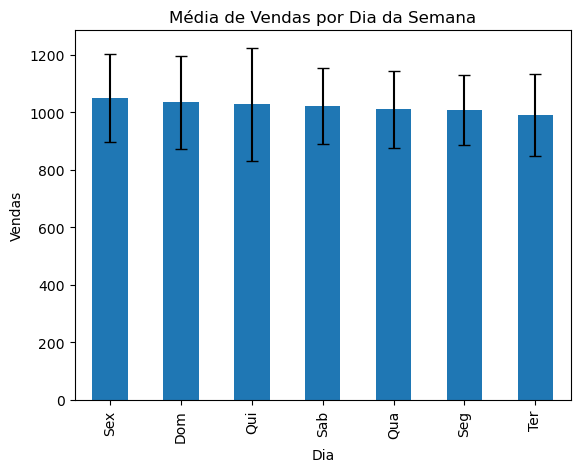

----------------------------------------------------------------------------------------------------------------------------------------



In [95]:
# Solução
resumo = round(vendas.groupby('Dia')['Vendas'].agg(['mean','std']).sort_values('mean', ascending= False),2)
resumo = resumo.rename(columns={ 'mean':'Média', 'std':'Desvio Padrão'})

resumo['Média'].plot(kind ='bar', yerr = resumo['Desvio Padrão'], capsize = 4)
plt.title("Média de Vendas por Dia da Semana")
plt.ylabel('Vendas')

print("------------- Relatório Variação Semanal de Vendas -------------\n")
print(resumo)
print("\nOs dias com maiores média de vendas são Sexta-Feira com R$ 1.049,79 e Domingo com R$ 1.034,72. Já a menor é Terça-Feira com apenas R$ 990,27.\n")
print("O desvio padrão é equilibrado durante os dias, tirando nas Quintas-Feiras que possui uma instabilidade maior.\n")
print("Em conclusão, as vendas se mantem estáveis com aumento nos fins de semanas.\n")
plt.show()
print("----------------------------------------------------------------------------------------------------------------------------------------\n")

#### Exercício 5: Estimativa da Média com Intervalo de Confiança (Statsmodels)

- Contexto: Um analista de RH quer estimar a altura média dos colaboradores com 95% de confiança.

- Tarefa: Calcule a média e o intervalo de confiança usando o DescrStatsW do Statsmodels. Interprete o resultado como se fosse parte de um relatório técnico.

- Resultado esperado: Apresente a altura média estimada e explique o significado do intervalo de confiança no contexto da amostra.

In [99]:
from statsmodels.stats.weightstats import DescrStatsW
# Seed
np.random.seed(7)

# Conjunto de dados
alturas = np.random.normal(1.75, 0.08, 40)

# Visualiza os dados
alturas

array([1.88524206, 1.71272501, 1.75262561, 1.7826013 , 1.68688616,
       1.75016525, 1.74992877, 1.60962206, 1.83141264, 1.79803988,
       1.69996568, 1.73627614, 1.79042395, 1.72909149, 1.73058007,
       1.63374069, 1.79436642, 1.75991047, 1.77195679, 1.62787804,
       1.88205598, 1.76234684, 1.7190288 , 1.91232578, 1.74636912,
       1.6339457 , 1.71758177, 1.56693479, 1.83395172, 1.71668205,
       1.69059572, 1.83579761, 1.61791395, 1.79283435, 1.58484682,
       1.69702725, 1.65366241, 1.86695805, 1.89129287, 1.7236469 ])

In [120]:
# Solução
relatorio = DescrStatsW(alturas)
media = round(float(relatorio.mean),2)
int_c = tuple(map(lambda x: round(float(x), 2), relatorio.tconfint_mean()))

print("------------- Relatório de Estimativa de Altura -------------\n")
print(f" A média estimada é: {media}. Tendo um intervalo de confiança de 95% indica alta probabiliade da média estar entre {int_c}, sendo assim é possível concluir devido a estimativa precisa uma variação em torno da média.\n")
print("----------------------------------------------------------------------------------------------------------------------------------------\n")

------------- Relatório de Estimativa de Altura -------------

 A média estimada é: 1.74. Tendo um intervalo de confiança de 95% indica alta probabiliade da média estar entre (1.71, 1.77), sendo assim é possível concluir devido a estimativa precisa uma variação em torno da média.

----------------------------------------------------------------------------------------------------------------------------------------



# Fim